In [7]:
import pandas as pd

df = pd.read_csv("../datasets/premier-league-matches.csv")

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(12026, 8)
   Season_End_Year  Wk        Date            Home  HomeGoals  AwayGoals  \
0             1993   1  1992-08-15   Coventry City          2          1   
1             1993   1  1992-08-15    Leeds United          2          1   
2             1993   1  1992-08-15   Sheffield Utd          2          1   
3             1993   1  1992-08-15  Crystal Palace          3          3   
4             1993   1  1992-08-15         Arsenal          2          4   

             Away FTR  
0   Middlesbrough   H  
1       Wimbledon   H  
2  Manchester Utd   H  
3       Blackburn   D  
4    Norwich City   A  
Season_End_Year    int64
Wk                 int64
Date                 str
Home                 str
HomeGoals          int64
AwayGoals          int64
Away                 str
FTR                  str
dtype: object
Season_End_Year    0
Wk                 0
Date               0
Home               0
HomeGoals          0
AwayGoals          0
Away               0
FTR                0
dtype:

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/premier-league-matches.csv")

df["result"] = df["FTR"].map({"H": "Home Win", "A": "Away Win", "D": "Draw"})
    
# print(df["result"].value_counts())
print(df["result"].value_counts(normalize=True).round(3))


result
Home Win    0.459
Away Win    0.284
Draw        0.258
Name: proportion, dtype: float64


In [ ]:
df.describe()

from sklearn.preprocessing import LabelEncoder

# temporary
le_temp = LabelEncoder()
df["result_encoded"] = le_temp.fit_transform(df["result"])

df.corr(numeric_only=True)["result_encoded"].sort_values()

AwayGoals         -0.624102
Season_End_Year   -0.028324
Wk                 0.016795
HomeGoals          0.619380
result_encoded     1.000000
Name: result_encoded, dtype: float64

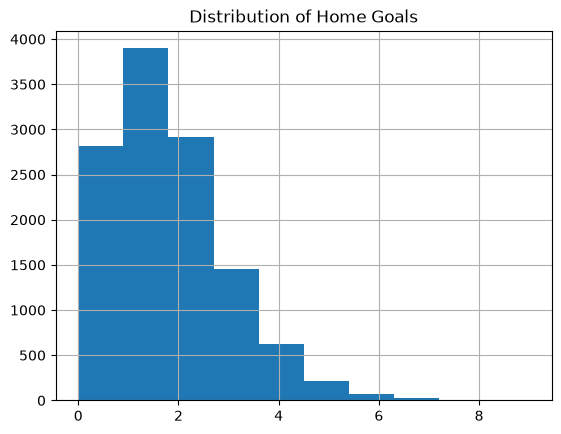

In [12]:
df["HomeGoals"].hist(bins=10)

plt.title("Distribution of Home Goals")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

df['result'] = df['FTR'].map({
    'H': 'Home Win',
    'A': 'Away Win',
    'D': 'Draw'
})

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['home_goals_avg'] = df.groupby('Home')['HomeGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['away_goals_avg'] = df.groupby('Away')['AwayGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['home_conceded_avg'] = df.groupby('Home')['AwayGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['away_conceded_avg'] = df.groupby('Away')['HomeGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df = df.dropna()

le_home = LabelEncoder()
le_away = LabelEncoder()
le_result = LabelEncoder()

df['home_encoded'] = le_home.fit_transform(df['Home'])
df['away_encoded'] = le_away.fit_transform(df['Away'])
df['result_encoded'] = le_result.fit_transform(df['result'])

In [14]:
from sklearn.model_selection import train_test_split

features = [
    'home_encoded',
    'away_encoded',
    'home_goals_avg',
    'away_goals_avg',
    'home_conceded_avg',
    'away_conceded_avg'
]

X = df[features]
y = df['result_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [24]:
predictions = model.predict(X_test)
print(predictions[:20])

pred_labels = le_result.inverse_transform(predictions[:20])
print(pred_labels)

[0 2 2 2 2 2 2 2 2 0 0 0 0 2 2 2 0 2 2 2]
['Away Win' 'Home Win' 'Home Win' 'Home Win' 'Home Win' 'Home Win'
 'Home Win' 'Home Win' 'Home Win' 'Away Win' 'Away Win' 'Away Win'
 'Away Win' 'Home Win' 'Home Win' 'Home Win' 'Away Win' 'Home Win'
 'Home Win' 'Home Win']


In [25]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, predictions))

0.4916317991631799


In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions, target_names=le_result.classes_))

              precision    recall  f1-score   support

    Away Win       0.43      0.31      0.36       654
        Draw       0.00      0.00      0.00       628
    Home Win       0.51      0.88      0.64      1108

    accuracy                           0.49      2390
   macro avg       0.31      0.40      0.33      2390
weighted avg       0.35      0.49      0.40      2390



c:\Users\natha\ip\ml\premier_league_predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\natha\ip\ml\premier_league_predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\natha\ip\ml\premier_league_predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

<Axes: >

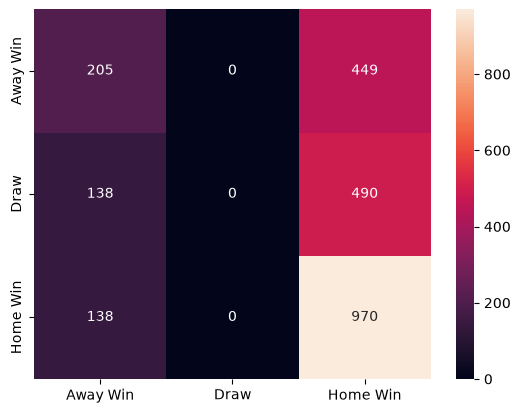

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Away Win', 'Draw', 'Home Win'],
    yticklabels=['Away Win', 'Draw', 'Home Win']
)